<a href="https://colab.research.google.com/github/DilemmaFixer3/svgm_labs/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Завдання 1

In [1]:
pip install owlready2 rdflib networkx matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.4/27.4 MB 45.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 39.2 MB/s eta 0:00:00
  Created wheel for owlready2: filename=owlready2-0.51-cp313-cp313-linux_x86_64.whl size=24780688 sha256=6cb16828cd6aca1c9b261aa8d50f89c765468aef052fd17888db0d054d90fa5f
  Stored in directory: /root/.cache/pip/wheels/cc/16/52/762fdfa8c53f256db44674790a3ceba702c3c763c96ce8b62c
Successfully built owlready2


In [2]:
"""
Завдання 1, Варіант 1
"""
from owlready2 import *

# 1. Створення онтології
onto = get_ontology("http://example.org/library_var1.owl")

with onto:
    # Базові класи
    class Book(Thing):
        """Клас Книга"""
        pass

    class Author(Thing):
        """Клас Автор"""
        pass

    class Publisher(Thing):
        """Клас Видавництво"""
        pass

    # Підкласи класу Book
    class EBook(Book):
        """Підклас Електронна книга"""
        pass

    class PrintedBook(Book):
        """Підклас Друкована книга"""
        pass

# 2. Збереження онтології у файл формату RDF/XML
file_name = "library_task1_var1.owl"
onto.save(file=file_name, format="rdfxml")
print(f"[OK] Онтологію бібліотеки збережено у файл '{file_name}'")

# 3. Виведення створеної ієрархії в консоль для звіту
print("\nСтворені класи та їхні типи:")
for cls in onto.classes():
    parents = [p.name for p in cls.is_a if isinstance(p, ThingClass)]
    print(f" - Клас: {cls.name} (Батьківські класи: {parents})")

[OK] Онтологію бібліотеки збережено у файл 'library_task1_var1.owl'

Створені класи та їхні типи:
 - Клас: Book (Батьківські класи: ['Thing'])
 - Клас: Author (Батьківські класи: ['Thing'])
 - Клас: Publisher (Батьківські класи: ['Thing'])
 - Клас: EBook (Батьківські класи: ['Book'])
 - Клас: PrintedBook (Батьківські класи: ['Book'])


Завдання 2

[OK] Онтологію збережено у mems_task2_var1.owl


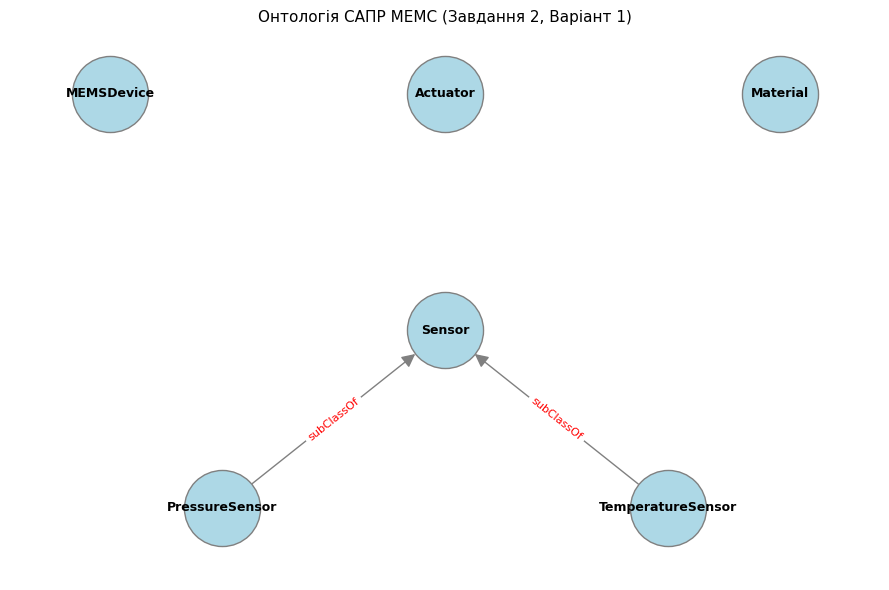

In [5]:
"""
Завдання 2 (Варіант 1)
"""
from rdflib import Graph, RDF, RDFS, OWL, Namespace
import networkx as nx
import matplotlib.pyplot as plt

# 1. Ініціалізація графу
g = Graph()
MEMS = Namespace("http://example.org/mems#")

# 2. Оголошення основних класів (MEMSDevice, Sensor, Actuator, Material)
main_classes = ["MEMSDevice", "Sensor", "Actuator", "Material"]
for c in main_classes:
    g.add((MEMS[c], RDF.type, OWL.Class))

# 3. Додавання підкласів лише до Sensor (згідно з пунктом 1 методички)
subclasses = ["PressureSensor", "TemperatureSensor"]
for sub in subclasses:
    g.add((MEMS[sub], RDF.type, OWL.Class))
    g.add((MEMS[sub], RDFS.subClassOf, MEMS.Sensor))

# Збереження онтології
g.serialize("mems_task2_var1.owl", format="xml")
print("[OK] Онтологію збережено у mems_task2_var1.owl")

# 4. Побудова графу в NetworkX
G = nx.DiGraph()

# Додаємо всі класи як вершини
for c in main_classes + subclasses:
    G.add_node(c)

# Додаємо лише змістовні зв'язки підкласів (subClassOf)
for s, p, o in g:
    s_label = str(s).split('#')[-1]
    p_label = str(p).split('#')[-1]
    o_label = str(o).split('#')[-1]

    if p_label == 'subClassOf':
        G.add_edge(s_label, o_label, label='subClassOf')

# 5. Фіксовані координати, щоб вузли не налізали один на одного
pos = {
    "MEMSDevice":        (0.2, 0.8),
    "Material":          (0.8, 0.8),
    "Actuator":          (0.5, 0.8),
    "Sensor":            (0.5, 0.4),
    "PressureSensor":    (0.3, 0.1),
    "TemperatureSensor": (0.7, 0.1)
}

plt.figure(figsize=(9, 6))

# Малюємо вузли
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=3000, edgecolors='gray')
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Малюємо стрілки від підкласів до Sensor
nx.draw_networkx_edges(
    G, pos,
    edge_color='gray',
    arrows=True,
    arrowsize=20,
    arrowstyle='-|>',
    node_size=3000
)

# Підписи над стрілками
edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

plt.title("Онтологія САПР МЕМС (Завдання 2, Варіант 1)", fontsize=11)
plt.axis('off')
plt.margins(0.15)
plt.tight_layout()
plt.show()